
K_R1s(r) =
+161.6444 * exp(-16.9317 r)
-337.5533 * r * exp(-23.6708 r)
+0.2333 * r * exp(-6.7720 r)
-1312.0589 * r^2 * exp(-20.5358 r)
-0.0116 * r^2 * exp(-4.0061 r)
-0.0005 * r^2 * exp(-2.4110 r)

K_R2s(r) =
-46.4349 * exp(-16.9317 r)
-61.8629 * r * exp(-23.6708 r)
+159.3010 * r * exp(-6.7720 r)
-557.9448 * r^2 * exp(-20.5358 r)
+1.0079 * r^2 * exp(-4.0061 r)
+0.0236 * r^2 * exp(-2.4110 r)

K_R3s(r) =
-15.3046 * exp(-16.9317 r)
-29.7715 * r * exp(-23.6708 r)
+62.1546 * r * exp(-6.7720 r)
-265.9827 * r^2 * exp(-20.5358 r)
-21.5656 * r^2 * exp(-4.0061 r)
-5.2214 * r^2 * exp(-2.4110 r)

K_R2p(r) =
+7.5536 * r * exp(-26.2044 r)
+173.7262 * r * exp(-11.1009 r)
+32.7546 * r * exp(-5.6095 r)
+0.0319 * r * exp(-2.4374 r)
+256.5016 * r^2 * exp(-8.7158 r)
-0.0022 * r^2 * exp(-1.9702 r)
+0.0001 * r^2 * exp(-1.3184 r)

K_R3p(r) =
+1.7737 * r * exp(-26.2044 r)
+37.2207 * r * exp(-11.1009 r)
+34.3270 * r * exp(-5.6095 r)
-8.2413 * r * exp(-2.4374 r)
+13.8806 * r^2 * exp(-8.7158 r)
-1.8291 * r^2 * 

/tmp/ipykernel_32364/1919059900.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.046374       1.854527e-01       5.697192e-01   
1       0.05           0.046373       1.853882e-01       5.677221e-01   
2       0.10           0.046370       1.851949e-01       5.617815e-01   
3       0.15           0.046365       1.848732e-01       5.520446e-01   
4       0.20           0.046357       1.844237e-01       5.387451e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000001       1.034284e-07       1.130090e-08   
1997   99.85           0.000001       1.029703e-07       1.125082e-08   
1998   99.90           0.000001       1.025137e-07       1.120091e-08   
1999   99.95           0.000001       1.020587e-07       1.115116e-08   
2000  100.00           0.000001       1.016053e-07       1.110159e-08   

      J_2p_one_electron  J_3p_one_electron  J_4s_one_electron   J_1s(2)  \
0          9.649733e-02       3.761284e-01      

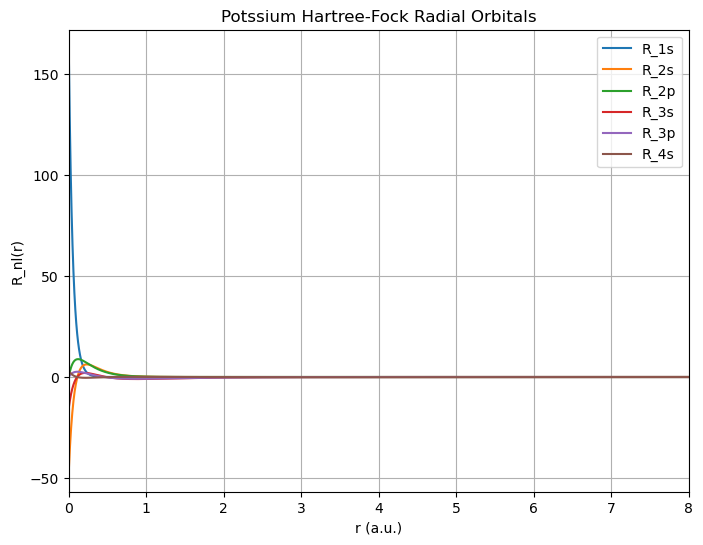

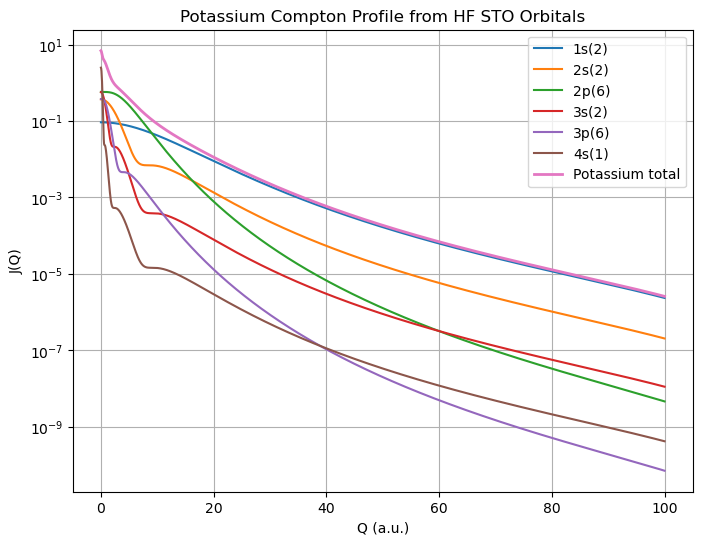

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Potassium Hartree-Fock STO data
# K: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 4s(1)
# Format: (n_j, Z_j, C_j)
# =====================================================

potassium_1s = [
    (1,16.9317,  1.160058),
    (2,23.6708, -0.107236),
    (2, 6.7720,  0.001693),
    (3,20.5358, -0.079291),
    (3, 4.0061, -0.000214),
    (3, 2.4110, -0.000052),
    (4, 8.4209, -0.000393),
    (4, 3.7899,  0.000116),
    (4, 1.4301,  0.000008),
    (4, 0.9450, -0.000005),
    (4, 0.6607,  0.000002),
]

potassium_2s = [
    (1,16.9317, -0.333245),
    (2,23.6708, -0.019653),
    (2, 6.7720,  1.155997),
    (3,20.5358, -0.033718),
    (3, 4.0061,  0.018576),
    (3, 2.4110,  0.002574),
    (4, 8.4209, -0.079850),
    (4, 3.7899, -0.007017),
    (4, 1.4301, -0.000286),
    (4, 0.9450,  0.000178),
    (4, 0.6607, -0.000064),
]

potassium_3s = [
    (1,16.9317, -0.109835),
    (2,23.6708, -0.009458),
    (2, 6.7720,  0.451036),
    (3,20.5358, -0.016074),
    (3, 4.0061, -0.397462),
    (3, 2.4110, -0.569061),
    (4, 8.4209,  0.037800),
    (4, 3.7899, -0.187652),
    (4, 1.4301, -0.007578),
    (4, 0.9450,  0.001939),
    (4, 0.6607, -0.000781),
]

potassium_4s = [
    (1,16.9317,  0.021207),
    (2,23.6708,  0.001900),
    (2, 6.7720, -0.088672),
    (3,20.5358,  0.003193),
    (3, 4.0061,  0.092956),
    (3, 2.4110,  0.106797),
    (4, 8.4209, -0.009891),
    (4, 3.7899, -0.045670),
    (4, 1.4301, -0.168271),
    (4, 0.9450, -0.520283),
    (4, 0.6607, -0.402360),
]

potassium_2p = [
    (2,26.2044, 0.001861),
    (2,11.1009, 0.366438),
    (2, 5.6095, 0.380621),
    (2, 2.4374, 0.002983),
    (3, 8.7158, 0.311226),
    (3, 1.9702,-0.000488),
    (3, 1.3184, 0.000071),
]

potassium_3p = [
    (2,26.2044,  0.000437),
    (2,11.1009,  0.078509),
    (2, 5.6095,  0.398893),
    (2, 2.4374, -0.769498),
    (3, 8.7158,  0.016842),
    (3, 1.9702, -0.404117),
    (3, 1.3184, -0.039862),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Potassium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, potassium_1s)
R2s = R_nl(r, potassium_2s)
R3s = R_nl(r, potassium_3s)
R2p = R_nl(r, potassium_2p)
R3p = R_nl(r, potassium_3p)
R4s = R_nl(r, potassium_4s)

print_R_formula(potassium_1s, "K_R1s")
print_R_formula(potassium_2s, "K_R2s")
print_R_formula(potassium_3s, "K_R3s")
print_R_formula(potassium_2p, "K_R2p")
print_R_formula(potassium_3p, "K_R3p")
print_R_formula(potassium_3p, "K_R4s")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4s = chi_p(p, r, R4s, l=0)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
# Potassium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(6) 4s(1)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": J_4s,
    "J_total_potassium": J_total
    })
print(table)
table.to_csv("Potassium_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Potssium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_3p, label="3p(6)")
plt.plot(Q, J_4s, label="4s(1)")
plt.plot(Q, J_total, label="Potassium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Potassium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()